<a href="https://colab.research.google.com/github/tlmakinen/degeneracy_distillery/blob/main/tutorial_notebooks/rosenbrock_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# degeneracy distillery demo

![Algorithm overview](https://github.com/tlmakinen/degeneracy_distillery/raw/main/docs/images/alg-cartoon-illustrated.png)

---

# Rosenbrock — Discovering $\eta$₂ = $\mu$₂ + $\mu$₁²

For the illustrations that follow we'll use a classic, difficult statistics problem to illustrate the distillery. The Rosenbrock function maps a "flat" 2D Gaussian mean, $\eta=(\nu_1,\nu_2)$, to a degenerate coordinate space $\theta=(\mu_1,\mu_2)$:

$$
    \mu_1 = \nu_1, \quad \mu_2 = \nu_2 + \nu_1^2,
    \quad \Leftrightarrow \quad
    \nu_1 = \mu_1, \quad \nu_2 = \mu_2 - \mu_1^2
$$

Here the data are noise generated from the means $\theta$ with fixed covariance $\Sigma$. The data here can be a very long vector: here we draw 50, 2D i.i.d. datapoints per parameter combination, resulting in a 100-dimensional data vector. This toy model is a difficult test problem for probabilistic methods because it yields posteriors $p(\theta \mid \textbf{x})$ that produce deep "U"-shaped valleys that are difficult to sample or "traverse". Our goal will be to uncover this "U" shape and learn the mapping $\eta(\theta)$ *from data and $\theta$ samples alone*.

Toy two-parameter inference task with a known **nonlinear** degeneracy.

* **Model**: $x \sim {N}(\boldsymbol{\mu}_x(\boldsymbol{\theta}), \Sigma)$ with
  $\boldsymbol{\mu}_x = (\theta_1,\, \theta_2 - \theta_1^2)^\top$ and
  $\Sigma = \mathrm{diag}(1, 4)$.
* **Data**: $n_d = 50$ i.i.d. draws from that distribution, flattened into
  one $100$-vector.
* **Ground truth**: $\eta_2 = \theta_2 + \theta_1^2$.

In [1]:
# Colab setup
!git clone https://github.com/tlmakinen/degeneracy_distillery.git
%cd /content/degeneracy_distillery
!pip install -q -e .
%cd /content/
!git clone https://github.com/DeaglanBartlett/ESR.git
%cd /content/ESR
!pip install -q -e .


Cloning into 'degeneracy_distillery'...
remote: Enumerating objects: 1196, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 1196 (delta 113), reused 115 (delta 87), pack-reused 1037 (from 2)
Receiving objects: 100% (1196/1196), 227.18 MiB | 24.76 MiB/s, done.
Resolving deltas: 100% (763/763), done.
Updating files: 100% (96/96), done.
/content/degeneracy_distillery
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Restart the runtime** before continuing on Colab.

In [ ]:
# Colab only: uncomment to hard-restart the runtime after the install above.
# Skip on a local Jupyter kernel — this will kill your session.
import os
os.kill(os.getpid(), 9)


In [1]:
import esr.generation.generator
import numpy as np
import jax, jax.numpy as jnp, jax.random as jr
import matplotlib.pyplot as plt
import sympy

from degeneracy_distillery.training_loop_fishnets import train_fishnets
from degeneracy_distillery.training_loop_flatten import fit_flattening
from degeneracy_distillery.align_coords import load_and_process_data_v2
from degeneracy_distillery.sr_utils import (
    fit_and_analyze_sr, analyze_equations, sr_structure_predicate,
    check_symbolic_invertibility,
    fit_theta_scaler, expressions_to_physical,
)
from degeneracy_distillery.postprocess_new import (
    analyze_atom_sharing, regroup_like_terms,
)
from degeneracy_distillery.postprocessing_utils import (
    print_discovered_expressions, get_y_sr,
    flatten_with_numerical_jacobian, check_flattening,
)
from degeneracy_distillery.preprocessing_utils import get_eigenvalues

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'figure.figsize': (8, 5),
    'figure.dpi': 130, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})


## Simulator and data generation

In [2]:
key = jr.PRNGKey(0)
dim, n_d = 2, 50
nsims = 250
MIN_MU, MAX_MU = -3.0, 3.0
Sigma = jnp.diag(jnp.array([1.0, 2.0]) ** 2)


def simulator(rng, theta):
    """x_mean = (theta1, theta2 - theta1**2); n_d i.i.d. draws."""
    x_mean = jnp.array([theta[0], theta[1] - theta[0] ** 2])
    return jr.multivariate_normal(rng, mean=x_mean, cov=Sigma, shape=(n_d,)).reshape(-1)


k1, k2 = jr.split(key)
theta_train = np.asarray(jr.uniform(k1, (nsims, dim), minval=MIN_MU, maxval=MAX_MU))
data_train  = np.asarray(jax.vmap(simulator)(jr.split(k1, nsims), theta_train))

theta_test = np.asarray(jr.uniform(k2, (nsims, dim), minval=MIN_MU, maxval=MAX_MU))
data_test  = np.asarray(jax.vmap(simulator)(jr.split(k2, nsims), theta_test))
print("theta_train", theta_train.shape, "data_train", data_train.shape)


theta_train (250, 2) data_train (250, 100)


In [17]:
#@title plotting code
def plot_labelled_datasets(data, theta, indices=(0, 1), n_d=50, dim=2, title="Simulated datasets"):
    """
    Plot selected simulated datasets, labelled by their parameter values.

    data:  array of shape (nsims, n_d * dim)
    theta: array of shape (nsims, dim)
    indices: which simulations to plot
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    for i in indices:
        x = data[i].reshape(n_d, dim)

        label = rf"$\theta=({theta[i,0]:.2f}, {theta[i,1]:.2f})$"

        ax.scatter(
            x[:, 0],
            x[:, 1],
            alpha=0.7,
            s=35,
            label=label
        )

        # Mark empirical mean
        xbar = x.mean(axis=0)
        ax.scatter(
            xbar[0],
            xbar[1],
            marker="x",
            s=120,
            linewidths=2
        )

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(title)

    # Legend outside, to the right
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        framealpha=0.0
    )

    # No grid
    ax.grid(False)

    plt.tight_layout()
    plt.show()

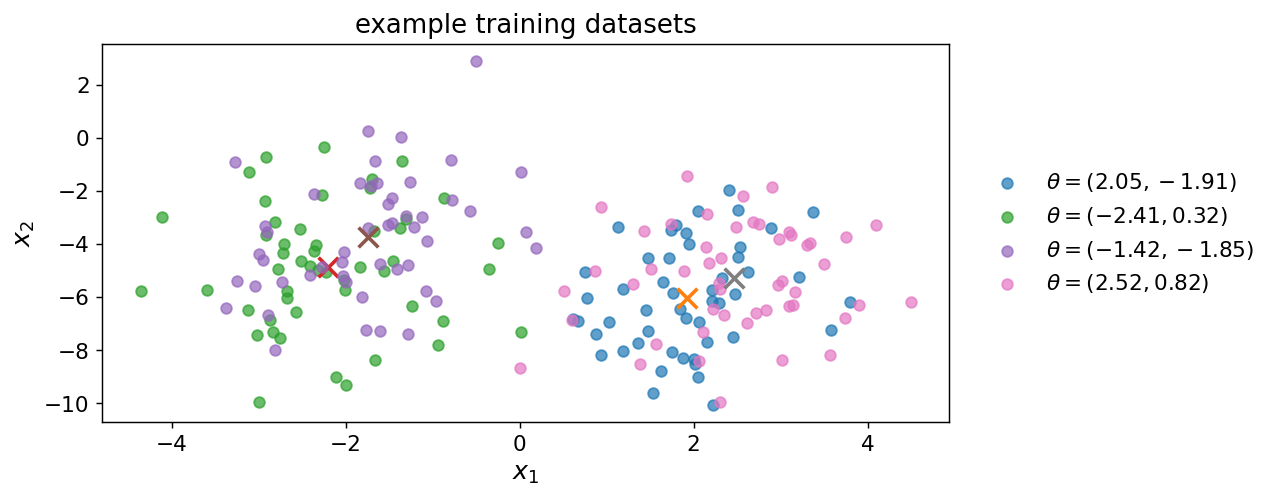

In [16]:
plot_labelled_datasets(
    data_train,
    theta_train,
    indices=(0, 5, 10, 20),
    n_d=n_d,
    dim=dim,
    title="example training datasets"
)

## Pre-fishnet rescaling

θ already lives in $[-3, 3]^2$, but applying the same `(1, 2)` scaling
keeps the convention shared across the tutorial notebooks and gives a
clean affine inverse for the final symbolic substitution.

In [ ]:
scaler = fit_theta_scaler(theta_train, feature_range=(-3.0, 3.0))
theta_train_s = scaler.transform(theta_train).astype(np.float32)
theta_test_s  = scaler.transform(theta_test).astype(np.float32)
print("scaled range:", theta_train_s.min(0), theta_train_s.max(0))


scaled range: [-3. -3.] [3.        3.0000005]


## 1. Fisher-network ensemble

*Information geometry* is how parameter uncertainty changes as the parameters change. We saw this above in our two toy examples: some parts of parameter space lead to bigger changes in data, others lead to smaller or no changes. This is encoded in changes in the likelihood of the data,  $p(\textbf{x}\mid \theta)$.

We can draw a map of where these sensitivities occur. For parameter values that very sensitively control the data, we might imagine the sharp peak of a high mountain, or a "hot" region on a weather heatmap. For regions of parameter space that don't impact the data much, we might think of a valley or a "cold" spot.

Mathematically, information geometry is described by the *Fisher Information Matrix*, which forms a metric, or underlying grid. Mathematicians often illustrate metrics locally as an ellipse. For flat regions, the ellipse looks circular (no preferred direction). For a "peak" or a "valley", we see the ellipse stretched in one preferred direction, indicating a slope or gradient in information space. Explicitly, each element of the Fisher information is given by:

$$
    F_{ab}({\theta}) = -\int {\rm d}\textbf{x}\ p(\textbf{x} | {\theta})\,
    \frac{\partial}{\partial {\theta}^a}\frac{\partial}{\partial {\theta}^b}
    \log p(\textbf{x} | {\theta}),
$$

which is usually read as an average over data realisations at a given parameter value.


But how do we obtain this topological map from data and parameters alone? We do this by asking a neural network to compress data into a Fisher matrix and parameter estimate at each point in parameter space, and then minimise the KL divergence for a Gaussian:

$$
L_{\rm fish}( \theta, (F_\theta, \hat{\theta})) = \frac{1}{2} (\hat{\theta} - \theta)^T F_\theta (\hat{\theta} - \theta) - \frac{1}{2} \log \det F_\theta
$$

In [ ]:
_ = train_fishnets(
    theta_train_s, data_train,
    theta_test_s,  data_test,
    num_models=20,
    hids_min=10, hids_max=300, n_layers=[2, 5],
    train_epochs=1000, train_min_epochs=100, patience=20,
    train_batch_size=25, lr=5e-5,
    seed_model=201, seed_train=999,
    outdir="fishnets-rosen",
)


saving to fishnets-rosen
data_test shape: (250, 100)
theta_test shape: (250, 2)
Chosen hidden size for model 1 : 299 | layers: 5
Chosen hidden size for model 2 : 210 | layers: 2
Chosen hidden size for model 3 : 176 | layers: 5
Chosen hidden size for model 4 : 159 | layers: 5
Chosen hidden size for model 5 : 215 | layers: 2
Chosen hidden size for model 6 : 203 | layers: 5
Chosen hidden size for model 7 : 34 | layers: 4
Chosen hidden size for model 8 : 245 | layers: 4
Chosen hidden size for model 9 : 289 | layers: 5
Chosen hidden size for model 10 : 291 | layers: 2
Chosen hidden size for model 11 : 214 | layers: 5
Chosen hidden size for model 12 : 98 | layers: 2
Chosen hidden size for model 13 : 100 | layers: 4
Chosen hidden size for model 14 : 124 | layers: 2
Chosen hidden size for model 15 : 39 | layers: 4
Chosen hidden size for model 16 : 31 | layers: 4
Chosen hidden size for model 17 : 93 | layers: 3
Chosen hidden size for model 18 : 185 | layers: 4
Chosen hidden size for model 19 : 

Epoch 246 loss: -3.55437 ; val_loss: 1.55987:  25%|██▍       | 246/1000 [00:12<00:37, 19.91it/s]



Early stopping triggered at epoch 246

Training model 2 of 20


Epoch 187 loss: -1.24298 ; val_loss: 2.73945:  19%|█▊        | 187/1000 [00:08<00:37, 21.82it/s]



Early stopping triggered at epoch 187

Training model 3 of 20


...


Early stopping triggered at epoch 339

Training model 19 of 20


Epoch 473 loss: -2.86005 ; val_loss: 0.81483:  47%|████▋     | 473/1000 [00:16<00:18, 28.50it/s]



Early stopping triggered at epoch 473

Training model 20 of 20


Epoch 383 loss: -1.71821 ; val_loss: -0.06517:  38%|███▊      | 383/1000 [00:12<00:20, 30.75it/s]



Early stopping triggered at epoch 383
Ensemble weights: [2.7785337  0.5508381  2.2859983  3.1734443  1.1346898  3.1366768
 0.60423833 0.5676466  2.6180408  0.8716843  2.3987622  1.1655751
 2.8988883  1.3112545  0.44983685 1.8209476  0.7934135  2.9508772
 1.4122185  1.1962796 ]
Training completed. Outputs saved to: fishnets-rosen/fishnets_outputs.npz
Note: Load with io_utils.load_fishnets_results(file) for alias support


## 2. Flattening Network

From information geometry, the Fisher matrix transforms from one coordinate system $\theta$, to another, $\eta$, via the transformation

$$
F_\eta = \frac{\partial \theta}{\partial \eta}^\top F_\theta  \frac{\partial \theta}{\partial \eta}.
$$

We can cast this as an objective for our degeneracy-resolving, or *flattener* network, using our $F_\theta$ learned in the previous step. A flat metric is just the identity in $n_\theta$. With some rearrangement, we obtain the flattening loss for the Fisher matrix in the new coordinate system,

$$
L_{\rm flat} = || J^{-\top} F_{\theta} J^{-1} - \mathbb{I} ||^2_{{F}},
$$

where
$ J = \frac{\partial \theta}{\partial \eta} $ is the Jacobian of the flattener network.

In [ ]:
fish = np.load("fishnets-rosen/fishnets_outputs.npz")
thetas = jnp.array(fish["theta"])
ensemble_weights = fish["ensemble_weights"]
F_network_ensemble = jnp.array(fish["Fs"])

w, ensemble_w, outputs_flatten, flatten_model = fit_flattening(
    F_network_ensemble, thetas,
    ensemble_weights=ensemble_weights,
    hidden_size=256, n_layers=7,
    batch_size=50,
    epochs_phase1=1000, epochs_phase2=2000, finetune_epochs=250,
    min_epochs=250, patience=40,
    lr_phase1=1e-6, lr_schedule_initial=7e-5, lr_decay=0.3, lr_finetune=4e-6,
    Fisher_to_flatten="average",
    norm_factor=None, norm_method="median_det",
    flattener_activation="softplus",
    noise=1e-4, seed=0,
    output_prefix="rosen_flatten",
    use_whitening=True, nn_inv=False,
    forward_backward_mlp=True,
    l1_alpha=0.0, do_plot=False,
    return_model=True
)


AVERAGING FISHERS (weighted ensemble)
COMPUTING ROBUST NORM FACTOR (method: median_det)
norm_factor = 9.85067
COMPUTING WHITENING TRANSFORM
Global mean Fisher shape: (2, 2)
Global mean Fisher:
[[ 9.927926   -0.48452547]
 [-0.48452547  0.55641407]]
Mean Fisher eigenvalues: [0.53142977 9.952909  ]
W_inv transformation:  [[ 3.1483903  -0.12475501]
 [-0.12475501  0.73542523]]
Whitened Fisher global mean (should be ~I):
[[9.9999994e-01 0.0000000e+00]
 [2.2351742e-08 1.0000001e+00]]
W_inv condition number: 4.33
Flattener activation: softplus
Loss type: log_frob
Min-max input scaling: True
Min-max post-scale offset: 0.1
USING WHITENED forward–backward MLP (forward WhitenedMLP + ReversePathMLP)
TRAINING FLATTENER NET


epoch 999 loss: 0.7702, det F(η): 2.0429, val det F(η): 1.6703: 100%|██████████| 1000/1000 [01:03<00:00, 15.72it/s]


FINE-TUNING FLATTENER NET


epoch 342 loss: 0.6200, det F(η): 1.0323, val det F(η): 0.8877:  17%|█▋        | 342/2000 [00:26<02:07, 12.97it/s]



 patience reached. stopping training.
FINE-TUNING EACH ENSEMBLE MEMBER
fine-tuning for ensemble member 0


...

fine-tuning for ensemble member 18


epoch 249 loss: 0.6550, det F(η): 1.0896, val det F(η): 0.9744: 100%|██████████| 250/250 [00:22<00:00, 11.05it/s]


fine-tuning for ensemble member 19


epoch 249 loss: 0.6644, det F(η): 0.9868, val det F(η): 1.0352: 100%|██████████| 250/250 [00:22<00:00, 11.16it/s]


applying model to ensemble member 0
applying model to ensemble member 1
applying model to ensemble member 2
applying model to ensemble member 3
applying model to ensemble member 4
applying model to ensemble member 5
applying model to ensemble member 6
applying model to ensemble member 7
applying model to ensemble member 8
applying model to ensemble member 9
applying model to ensemble member 10
applying model to ensemble member 11
applying model to ensemble member 12
applying model to ensemble member 13
applying model to ensemble member 14
applying model to ensemble member 15
applying model to ensemble member 16
applying model to ensemble member 17
applying model to ensemble member 18
applying model to ensemble member 19
ROTATING ENSEMBLE COORDINATES
Note: Load with io_utils.load_flattening_results(file) for alias support
EXPERIMENT COMPLETED & RESULTS SAVED TO: rosen_flatten.npz
Saved flattener module + weights to: rosen_flatten_flatten_model.pkl


## 5. Coordinate alignment

In [ ]:
data = load_and_process_data_v2(
    datapath="./",
    filename="rosen_flatten.npz",
    num_samps=4000, seed=44,
    process_ensemble=True, n_d=1.0,
    align_mode="procrustes",
    separate_nonlinearity=True,
    canonicalize="sign_only",
    use_prior_normalization=True,
    restore_reference_mean=False,
    Fisher_to_flatten="average",
    verbose=False,
)

X = data["X"]
X, y, y_std, dy_sr, Fs = X, data["y"], data["y_std"], data["dy_sr"], data["Fs"]
min_ = y.min(0)
y -= min_
ys = data["ys"] - min_
n_params = X.shape[1]
print("aligned X", X.shape, "y", y.shape)


aligned X (250, 2) y (250, 2)


### data augmentation for symbolic regression
We have a model for $\theta \rightarrow \eta$. Now we are free to generate loads of examples of $X=\theta$ and corresponding outputs $y=\eta$ to fit SR to.

In [ ]:
from degeneracy_distillery.postprocessing_utils import weighted_std

X_sr = jr.uniform(key, minval=X.min(0), maxval=X.max(0), shape=(2000, 2))

ys_sr = jnp.array([jax.vmap(lambda x: flatten_model.apply(w_i, x))(X_sr) for w_i in ensemble_w])

ys_sr_rot = np.array([
    np.einsum("ij,bj->bi", data['rotmats'][i], ys_sr[i] - ys_sr[i].mean(0))
    for i in range(len(ys_sr))
])

y_std_sr = weighted_std(ys_sr_rot, data['ensemble_weights'])
y_sr = np.average(ys_sr_rot, 0, data['ensemble_weights'])
ys_sr_rot -= y_sr.min(0)
y_sr -= y_sr.min(0)

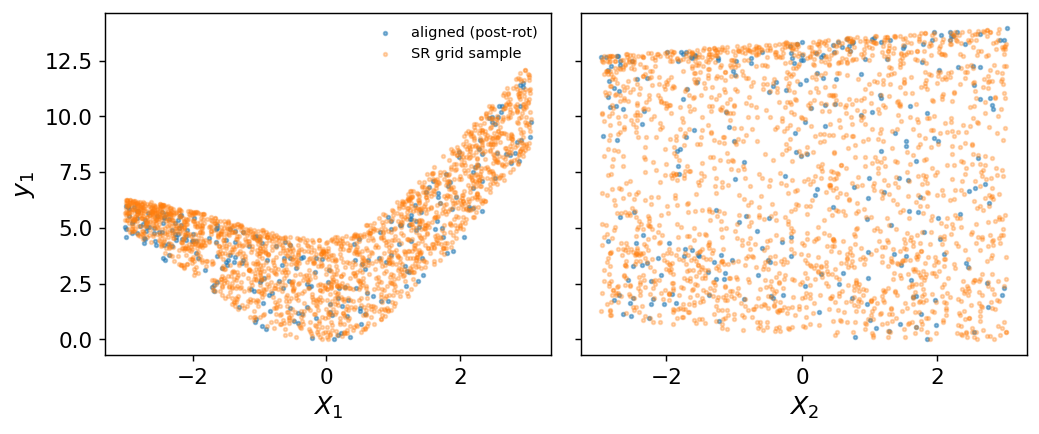

In [ ]:
# Quick sanity check: each aligned y component vs the SR-grid X coordinates.
fig, axs = plt.subplots(1, n_params, figsize=(8, 3.5), sharey=True)
for j, ax in enumerate(axs):
    ax.scatter(X[:, j],    y[:, j],    s=4, alpha=0.5, label="aligned (post-rot)")
    ax.scatter(X_sr[:, j], y_sr[:, j], s=4, alpha=0.3, label="SR grid sample")
    ax.set_xlabel(rf"$X_{j+1}$")
    ax.set_ylabel(rf"$y_{j+1}$" if j == 0 else "")
axs[0].legend(loc="best", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

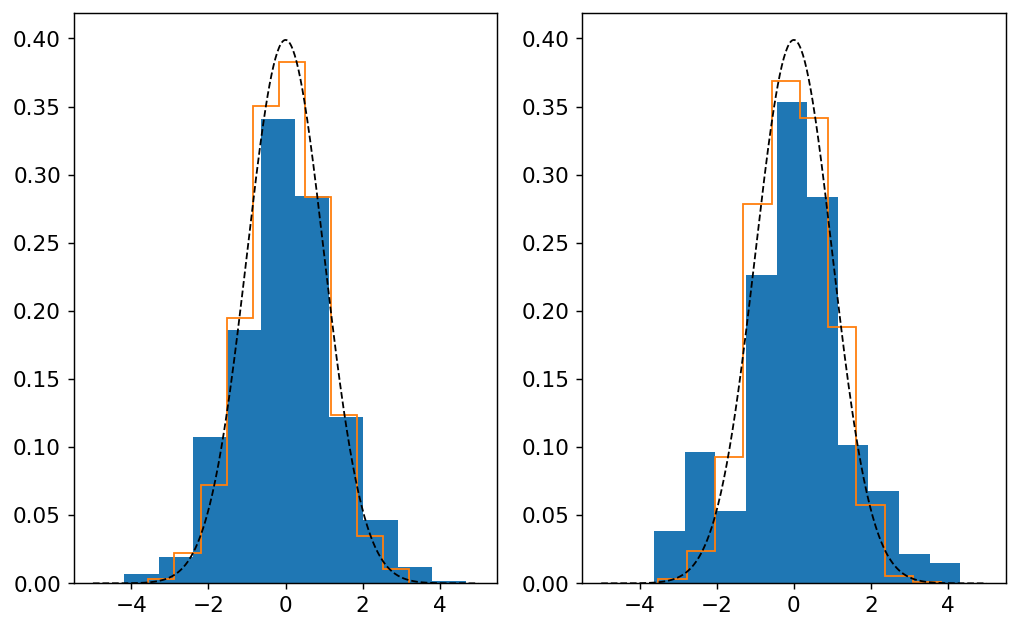

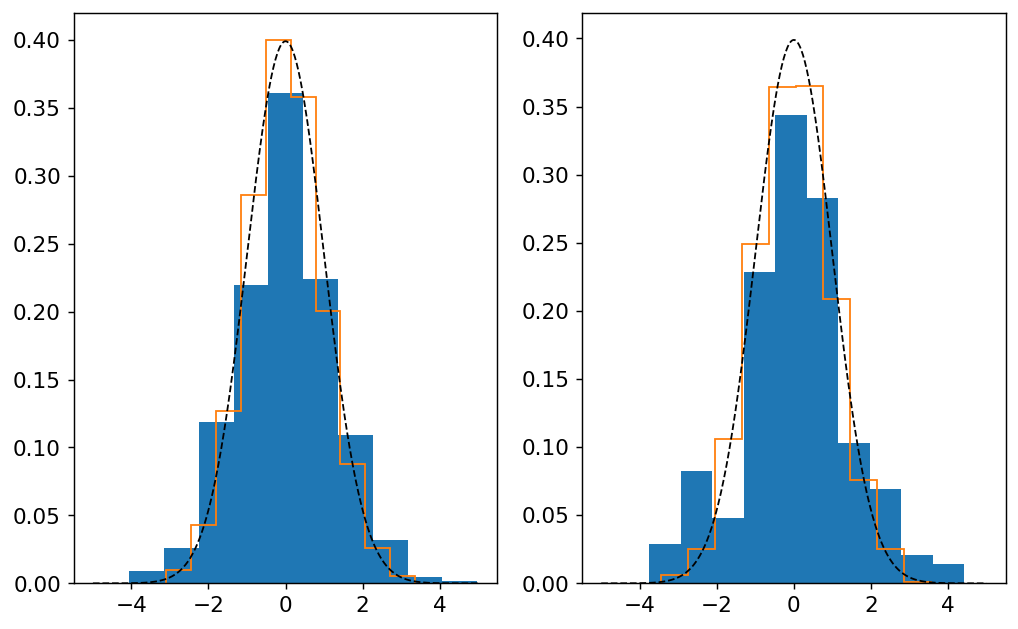

In [ ]:
# check coordinate sampling distribution --> should be close to gaussian.

fig,axs = plt.subplots(1,n_params)
axs = axs.flatten()

bins = [-5, 5]

for i,ax in enumerate(axs):
    ax.hist(((ys[:, :, ...] - y) / y_std)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)
    ax.plot(xpdf, ypdf, lw=1.0, c="k", ls="--", label="Normal")

    # ax.set_xlim(-10, 10)
plt.tight_layout()
plt.show()


fig,axs = plt.subplots(1,n_params)
axs = axs.flatten()

bins = [-5, 5]

for i,ax in enumerate(axs):
    ax.hist(((ys_sr_rot - y_sr) / y_std_sr)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)
    ax.plot(xpdf, ypdf, lw=1.0, c="k", ls="--", label="Normal")

    # ax.set_xlim(-10, 10)
plt.tight_layout()
plt.show()

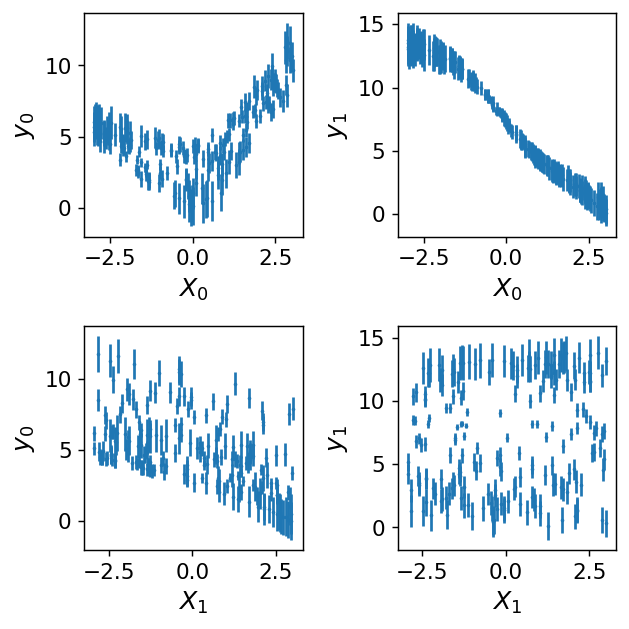

In [ ]:
# create scatterplot to see how y responds to X

fig, axs = plt.subplots(n_params, n_params, figsize=(5,5))

skip=10

for i in range(X_sr.shape[-1]):
    for j in range(y_sr.shape[-1]):

        # row, column
        axs[i,j].errorbar(X_sr[::skip,i], y_sr[::skip, j], yerr=y_std_sr[::skip, j], label='', fmt='o', markersize=1)

        axs[i,j].set_xlabel(r"$X_%d$"%(i))
        axs[i,j].set_ylabel(r"$y_%d$"%(j))

plt.tight_layout()
plt.show()

## 6. Symbolic regression

In [ ]:
from degeneracy_distillery.sr_utils import fit_symbolic_regression

fit_symbolic_regression(
    X_sr, y_sr, y_std_sr,
    parent_dir='./sr_results_rosen/',
    random_state=32134,
    time_limit=60*5,
    max_length=25,
    max_depth=10,
    allowed_symbols='add,mul,div,pow,constant,variable,square',
    )


Fitting component 1 of 2 (index 0)
X train shape: (2000, 2), y train shape: (2000,)
Fitting...
Done!
Best model: (0.00 + (1.00 * ((2.52 + ((((-1.07) * X1) ^ 2) + ((-0.76) * X2))) * ((1.02 + ((-0.01) * X1)) ^ (4.44 * X1)))))
Stats: {'model_length': 16, 'model_complexity': 24, 'generations': 241, 'evaluation_count': 0, 'residual_evaluations': 1834683, 'jacobian_evaluations': 1169153, 'random_state': 32134}
Outputting 19 individuals on Pareto front
Outputting 2000 individuals in population

Fitting component 2 of 2 (index 1)
X train shape: (2000, 2), y train shape: (2000,)
Fitting...
Done!
Best model: ((-0.05) + (1.01 * (((((3.19 * X1) ^ 2) ^ (0.04 * X1)) * (((-0.35) * X2) + ((((-0.69) * X1) + 2.70) ^ 2))) + (0.40 * X2))))
Stats: {'model_length': 17, 'model_complexity': 27, 'generations': 232, 'evaluation_count': 0, 'residual_evaluations': 1892957, 'jacobian_evaluations': 1227173, 'random_state': 32134}
Outputting 20 individuals on Pareto front
Outputting 2000 individuals in population


In [ ]:
from degeneracy_distillery.sr_utils import analyze_equations, sr_structure_predicate

X_test, y_test, y_std_test = X, y, y_std
dy_sr_test, Fs_test = dy_sr, Fs

mdl_coords, frob_coords, analysis = analyze_equations(
    X_test, y_test, y_std_test, dy_sr_test, Fs_test,
    parent_dir="sr_results_rosen/",
    n_params=n_params,
    equation_set="pareto",
    max_complexity_thresh=15,
    length_penalty=3.0,
    equation_predicate=sr_structure_predicate(
        n_params=2,
        forbid_self_transcendental=True,
    ),
)
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in mdl_coords])



Analysing component 1 of 2 (index 0)
Loading equations from: pareto.csv
9 equations below complexity threshold 15
6 / 9 equations pass equation_predicate (skipped 3)

Best MDL equation (complexity=10):
  (2.821085 + (0.784173 * ((((0.908024 * X1) ^ 2) + ((-0.832460) * X2)) + (0.803155 * X1))))
  LaTeX: $b_{0} + b_{1} \left(X_{1}^{2} b_{2}^{2} + X_{1} b_{4} + X_{2} b_{3}\right)$

Best Frob loss equation (complexity=13):
  (2.451912 + (0.932967 * ((((-0.668987) * X2) + (0.640761 * X1)) + ((((1.062930 * X1) ^ 2) ^ 0.402573) ^ 2))))
  LaTeX: $b_{0} + b_{1} \left(X_{1} b_{3} + X_{2} b_{2} + \left(X_{1}^{2} b_{4}^{2}\right)^{2 b_{5}}\right)$

Analysing component 2 of 2 (index 1)
Loading equations from: pareto.csv
8 equations below complexity threshold 15
1 / 8 equations pass equation_predicate (skipped 7)

Best MDL equation (complexity=5):
  (7.334030 + ((-2.768502) * (0.879501 * X1)))
  LaTeX: $X_{1} b_{1} b_{2} + b_{0}$

Best Frob loss equation (complexity=5):
  (7.334030 + ((-2.768502) *

## 7. Postprocessing (`postprocess_new`)

In [ ]:
report = analyze_atom_sharing(mdl_coords)
pruned_exprs, R, info = regroup_like_terms(
    mdl_coords, X=X_test, Fs=Fs_test, n_params=n_params,
    method="atoms",
    do_snap=True, snap_rel_tol=0.5, snap_flat_tol=0.5,
    decimal=2, threshold=2.0,
)
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in pruned_exprs])
# inv = check_symbolic_invertibility(pruned_exprs, verbose=True)
# print("inverse coords:", inv["inv_coords"])



extract_atoms: 2 rows, 4 unique atoms, ||C||_1 = 14.5192
reference flatness score: 1.114331
  outer  1/5: ||R C||_1 = 14.9739 (best 14.9739)
  outer  2/5: ||R C||_1 = 14.8902 (best 14.8902)
  outer  3/5: ||R C||_1 = 14.7841 (best 14.7841)
  outer  4/5: ||R C||_1 = 14.7246 (best 14.7246)
  outer  5/5: ||R C||_1 = 14.6909 (best 14.6909)
  done. L1 14.5192 -> 14.6909; exact-zero fraction 25.00% -> 0.00%; ortho err 1.89e-07
post-rotation flatness: 1.438496 (rel Δ = 29.09%, tol = 10.00%)
rotation rejected (flatness degraded too much); falling back to input expressions.
snapping shared coefficients...
  snapped atom '1'                                        across rows [np.int64(0), np.int64(1)] -> 5.078 (spread 44.44%, Δflat 0.03%)
final flatness: 1.114040
snapping inner-factor coefficients...
final flatness after inner snap: 1.114040

DISCOVERED EXPRESSIONS
  η_1 = 0.65*X1**2 + 0.63*X1 - 0.65*X2 + 5.1
  η_2 = 5.1 - 2.4*X1


## 8. Back to physical θ

The flattened-frame X coords are in `[1, 2]`; substituting
$X_i = a_i \theta_i + b_i$ via `expressions_to_physical` recovers the
discovered formulas in $(\theta_1, \theta_2)$.  We expect one component
proportional to $\theta_2 + \theta_1^2$.

In [ ]:
physical_exprs = expressions_to_physical(
    pruned_exprs, scaler,
    sr_offset=0.0,                 # this notebook does not +1 the SR inputs
    theta_names=("theta1", "theta2"),
    decimal=3,
)
for k, e in enumerate(physical_exprs):
    print(f"  eta_{k} = {e}")


  eta_0 = 0.67*theta1**2 + 0.686*theta1 - 0.657*theta2 + 5.097
  eta_1 = 4.996 - 2.478*theta1


## 9. Validation: flatness eigenvalues

A successful flattening drives the eigenvalues of the network Fisher in the
learned coordinates toward 1.0. Let's see how we did:

  raw θ     median ||Q-I||_F = 9.872
  MDL       median ||Q-I||_F = 0.892
  pruned    median ||Q-I||_F = 0.893
  NN        median ||Q-I||_F = 0.355


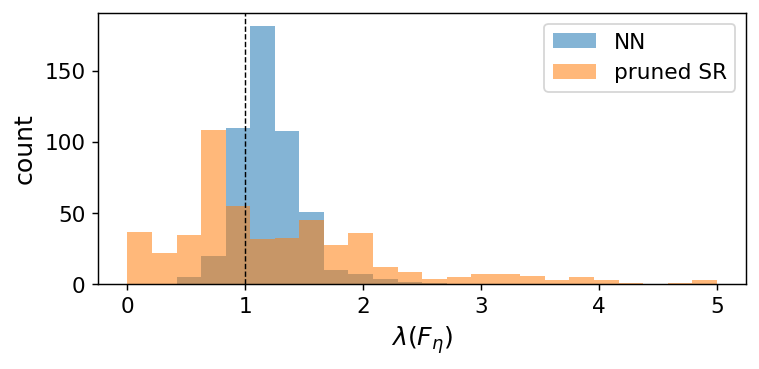

In [ ]:
nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy_sr_test, Fs_test)
mdl_flats, _    = check_flattening(mdl_coords,    X=X_test, Fs=Fs_test)
pruned_flats, _ = check_flattening(pruned_exprs,  X=X_test, Fs=Fs_test)


def fro_score(Q):
    return np.linalg.norm(np.asarray(Q) - np.eye(n_params), axis=(-2, -1))


for name, Q in [("raw θ", Fs_test),
                ("MDL",   mdl_flats),
                ("pruned", pruned_flats),
                ("NN",    nn_flats)]:
    print(f"  {name:8s}  median ||Q-I||_F = {np.median(fro_score(Q)):.3f}")

evalues_nn     = jax.vmap(get_eigenvalues)(nn_flats)
evalues_pruned = jax.vmap(get_eigenvalues)(pruned_flats)

bins = np.linspace(0, 5, 25)
plt.figure(figsize=(6, 3))
plt.hist(np.array(evalues_nn).flatten(),     bins=bins, alpha=0.55, label="NN")
plt.hist(np.array(evalues_pruned).flatten(), bins=bins, alpha=0.55, label="pruned SR")
plt.axvline(1.0, ls="--", color="k", lw=0.8)
plt.xlabel(r"$\lambda(F_\eta)$"); plt.ylabel("count"); plt.legend()
plt.tight_layout()
plt.show()


## 10. Save artifacts

In [ ]:
import pickle, os
os.makedirs("sr_results_rosen", exist_ok=True)
with open("sr_results_rosen/sr_expressions.pkl", "wb") as f:
    pickle.dump({
        "mdl_coords":      mdl_coords,
        "frob_coords":     frob_coords,
        "pruned_exprs":    pruned_exprs,
        "physical_exprs":  [str(e) for e in physical_exprs],
        "scaler_scale":    scaler.scale_,
        "scaler_min":      scaler.min_,
        "scaler_data_min": scaler.data_min_,
        "scaler_data_max": scaler.data_max_,
    }, f)
print("saved sr_results_rosen/sr_expressions.pkl")


In [ ]:
!cp -r fishnets-rosen/ sr_results_rosen/
!cp rosen_flatten.npz sr_results_rosen/
!zip -r sr_results_rosen_tiny.zip sr_results_rosen/